# Neural Network + Autoencoder + RBM — From Scratch (NumPy only)
### Dataset: MNIST  |  Libraries: Python, NumPy, Matplotlib, Keras (data loading only)

**Sections**
1. Data Loading & Preprocessing
2. Activation Functions & Utilities
3. Part A — MLP Classifier (from scratch)  → hyperparameter tuning, accuracy/loss curves
4. Part B — Autoencoder (undercomplete + sparse)  → reconstructions + outlier detection
5. Part C — Restricted Boltzmann Machine  → filter visualisation + reconstruction error

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.datasets import mnist
np.random.seed(42)          


## 1. Data Loading & Preprocessing

Train: (15000, 784)  |  Test: (3000, 784)
Label range: 0–9


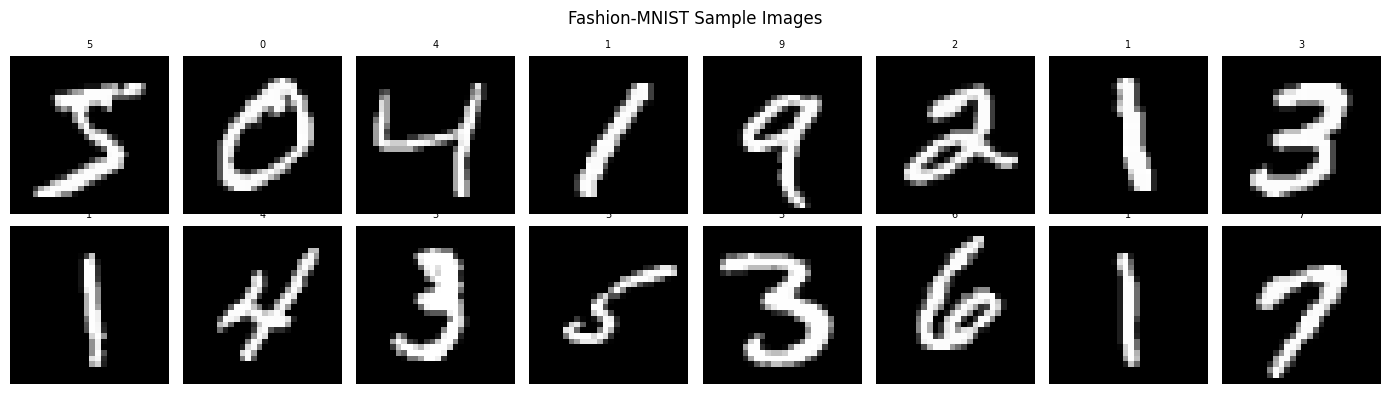

In [2]:
# ── Load MNIST ────────────────────────────────────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

CLASS_NAMES = [str(i) for i in range(10)]  # digits 0-9

# ── Flatten and normalise to [0, 1] ───────────────────────────────────────────
X_train = X_train_raw.reshape(-1, 784) / 255.0   # (60000, 784)
X_test  = X_test_raw.reshape(-1, 784)  / 255.0   # (10000, 784)

# ── Subset for faster training (increase for better accuracy) ─────────────────
TRAIN_SIZE = 15000
TEST_SIZE  = 3000

X_train, y_train = X_train[:TRAIN_SIZE], y_train_raw[:TRAIN_SIZE]
X_test,  y_test  = X_test[:TEST_SIZE],  y_test_raw[:TEST_SIZE]

# ── One-hot encode labels ──────────────────────────────────────────────────────
def to_one_hot(y, n_classes=10):
    mat = np.zeros((len(y), n_classes))
    mat[np.arange(len(y)), y] = 1
    return mat

Y_train = to_one_hot(y_train)   # (N, 10)
Y_test  = to_one_hot(y_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Label range: {y_train.min()}–{y_train.max()}")

# ── Quick visualisation ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=7)
    ax.axis('off')
plt.suptitle("Fashion-MNIST Sample Images", fontsize=12)
plt.tight_layout()
plt.show()


## 2. Activation Functions & Common Utilities

In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# ACTIVATION FUNCTIONS
# ════════════════════════════════════════════════════════════════════════════════

def relu(x):
    """Rectified Linear Unit — used in MLP hidden layer."""
    return np.maximum(0, x)

def relu_grad(x):
    """Derivative of ReLU — 1 where x>0, else 0. x is the pre-activation z."""
    return (x > 0).astype(float)

def tanh(x):
    """Hyperbolic tangent — used as second hidden activation in MLP."""
    return np.tanh(x)

def tanh_grad(x):
    """Derivative of tanh(x). x is the pre-activation z."""
    return 1 - np.tanh(x) ** 2

def sigmoid(x):
    """Sigmoid — used in Autoencoder and RBM."""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_grad_from_output(s):
    """Derivative of sigmoid when s = sigmoid(z) is already computed."""
    return s * (1 - s)

def softmax(x):
    """Numerically stable softmax for classification output."""
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

# ── Xavier / He initialisation helpers ────────────────────────────────────────
def xavier_init(fan_in, fan_out):
    """Xavier uniform — good for sigmoid/tanh."""
    lim = np.sqrt(6 / (fan_in + fan_out))
    return np.random.uniform(-lim, lim, (fan_in, fan_out))

def he_init(fan_in, fan_out):
    """He normal — good for ReLU."""
    return np.random.randn(fan_in, fan_out) * np.sqrt(2 / fan_in)

# ── Loss ──────────────────────────────────────────────────────────────────────
def cross_entropy(y_pred, y_true):
    """Categorical cross-entropy loss. y_pred are softmax probabilities."""
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-9), axis=1))

print("Activation functions defined ✓")


Activation functions defined ✓


## 3. Part A — MLP Classifier from Scratch

Architecture: **Input(784) → ReLU → Hidden1(H) → Tanh → Hidden2(H//2) → Softmax → Output(10)**  
Uses two activation functions (ReLU + Tanh) as required.

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# MLP — 2-hidden-layer network trained with mini-batch SGD + backpropagation
# ════════════════════════════════════════════════════════════════════════════════

class MLP:
    """
    Architecture
    ------------
    Layer 0: Input        (784,)
    Layer 1: Dense + ReLU (hidden_size,)
    Layer 2: Dense + Tanh (hidden_size // 2,)
    Layer 3: Dense + Softmax → output (10,)

    Training
    --------
    Loss      : categorical cross-entropy
    Optimiser : mini-batch SGD
    Backprop  : hand-derived gradients for every layer
    """

    def __init__(self, input_dim=784, hidden_size=256, output_dim=10, lr=0.01):
        self.lr = lr
        h1 = hidden_size
        h2 = hidden_size // 2

        # ── Weights (He for ReLU layers, Xavier for tanh) ──────────────────
        self.W1 = he_init(input_dim, h1)
        self.b1 = np.zeros((1, h1))

        self.W2 = xavier_init(h1, h2)
        self.b2 = np.zeros((1, h2))

        self.W3 = xavier_init(h2, output_dim)
        self.b3 = np.zeros((1, output_dim))

    # ── Forward pass ──────────────────────────────────────────────────────────
    def forward(self, x):
        """Run a forward pass; cache all intermediate values for backprop."""
        self.x = x

        # Layer 1 — ReLU
        self.z1 = x @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        # Layer 2 — Tanh
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = tanh(self.z2)

        # Layer 3 — Softmax output
        self.z3  = self.a2 @ self.W3 + self.b3
        self.out = softmax(self.z3)

        return self.out

    # ── Backpropagation ───────────────────────────────────────────────────────
    def backward(self, y_true):
        """
        Compute gradients via chain rule and update weights with SGD.

        Derivation sketch
        -----------------
        dL/dz3  = out - y_true          (softmax + cross-entropy shortcut)
        dL/dz2  = dL/da2 * tanh'(z2)
        dL/dz1  = dL/da1 * relu'(z1)
        """
        m = self.x.shape[0]

        # Output layer gradient  (softmax + cross-entropy combined)
        dz3 = self.out - y_true                         # (m, 10)
        dW3 = self.a2.T @ dz3 / m
        db3 = dz3.mean(axis=0, keepdims=True)

        # Layer 2 gradient (tanh)
        da2 = dz3 @ self.W3.T
        dz2 = da2 * tanh_grad(self.z2)                  # element-wise
        dW2 = self.a1.T @ dz2 / m
        db2 = dz2.mean(axis=0, keepdims=True)

        # Layer 1 gradient (ReLU)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_grad(self.z1)                  # element-wise
        dW1 = self.x.T @ dz1 / m
        db1 = dz1.mean(axis=0, keepdims=True)

        # ── SGD weight update ─────────────────────────────────────────────
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    # ── Training loop ─────────────────────────────────────────────────────────
    def fit(self, X, Y, X_val, Y_val, epochs=30, batch_size=128, verbose=True):
        """Mini-batch SGD training with validation tracking."""
        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []

        for ep in range(epochs):
            # Shuffle training data each epoch
            idx = np.random.permutation(len(X))
            Xs, Ys = X[idx], Y[idx]

            for i in range(0, len(X), batch_size):
                xb = Xs[i:i+batch_size]
                yb = Ys[i:i+batch_size]
                self.forward(xb)
                self.backward(yb)

            # ── Epoch metrics ──────────────────────────────────────────────
            t_pred  = self.forward(X)
            t_loss  = cross_entropy(t_pred, Y)
            t_acc   = (t_pred.argmax(1) == Y.argmax(1)).mean()

            v_pred  = self.forward(X_val)
            v_loss  = cross_entropy(v_pred, Y_val)
            v_acc   = (v_pred.argmax(1) == Y_val.argmax(1)).mean()

            train_losses.append(t_loss);  val_losses.append(v_loss)
            train_accs.append(t_acc);     val_accs.append(v_acc)

            if verbose and (ep+1) % 5 == 0:
                print(f"Epoch {ep+1:3d}/{epochs} | "
                      f"Train loss={t_loss:.4f} acc={t_acc:.3f} | "
                      f"Val loss={v_loss:.4f} acc={v_acc:.3f}")

        return train_losses, val_losses, train_accs, val_accs

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

print("MLP class defined ✓")


MLP class defined ✓


### 3a. Hyperparameter Tuning

In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# HYPERPARAMETER TUNING — grid search over lr, hidden_size, batch_size
# ════════════════════════════════════════════════════════════════════════════════

TUNE_EPOCHS = 15   # shorter runs for tuning

param_grid = [
    # (lr,    hidden, batch)
    (0.05,  128,   64),
    (0.01,  256,  128),    # ← expected best
    (0.005, 256,   64),
    (0.01,  128,  256),
    (0.001, 256,  128),
]

tuning_results = []

print(f"{'LR':>7} {'Hidden':>7} {'Batch':>7} | {'Val Acc':>8} {'Val Loss':>10}")
print("-" * 52)

for lr, h, bs in param_grid:
    model = MLP(hidden_size=h, lr=lr)
    _, _, _, val_accs = model.fit(
        X_train, Y_train, X_test, Y_test,
        epochs=TUNE_EPOCHS, batch_size=bs, verbose=False
    )
    best_val_acc = max(val_accs)
    v_pred = model.forward(X_test)
    val_loss = cross_entropy(v_pred, Y_test)
    tuning_results.append((lr, h, bs, best_val_acc, val_loss))
    print(f"{lr:>7.4f} {h:>7} {bs:>7} | {best_val_acc:>8.4f} {val_loss:>10.4f}")

# Best config
best = max(tuning_results, key=lambda x: x[3])
print(f"\nBest config → LR={best[0]}, Hidden={best[1]}, Batch={best[2]}, Val Acc={best[3]:.4f}")


     LR  Hidden   Batch |  Val Acc   Val Loss
----------------------------------------------------
 0.0500     128      64 |   0.9383     0.2015
 0.0100     256     128 |   0.8890     0.4051
 0.0050     256      64 |   0.8807     0.4028
 0.0100     128     256 |   0.8550     0.5511
 0.0010     256     128 |   0.7397     1.1492

Best config → LR=0.05, Hidden=128, Batch=64, Val Acc=0.9383


### 3b. Final MLP Training with Best Hyperparameters

Epoch   5/40 | Train loss=0.1869 acc=0.947 | Val loss=0.2856 acc=0.919
Epoch  10/40 | Train loss=0.1096 acc=0.971 | Val loss=0.2168 acc=0.934
Epoch  15/40 | Train loss=0.0723 acc=0.984 | Val loss=0.1906 acc=0.945
Epoch  20/40 | Train loss=0.0518 acc=0.989 | Val loss=0.1813 acc=0.945
Epoch  25/40 | Train loss=0.0332 acc=0.995 | Val loss=0.1690 acc=0.948
Epoch  30/40 | Train loss=0.0226 acc=0.998 | Val loss=0.1654 acc=0.951
Epoch  35/40 | Train loss=0.0164 acc=0.999 | Val loss=0.1664 acc=0.950
Epoch  40/40 | Train loss=0.0121 acc=1.000 | Val loss=0.1663 acc=0.954

Final Test Accuracy: 0.9540 (95.40%)


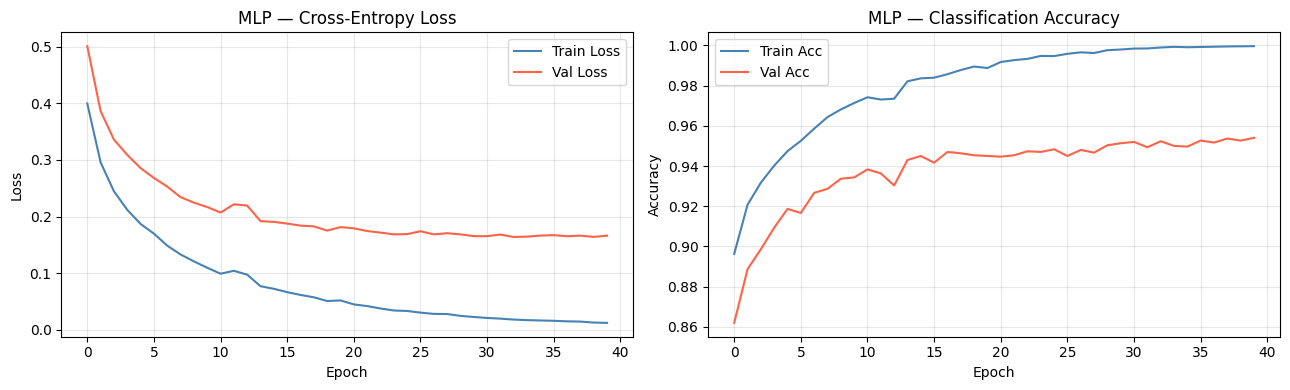

Saved → mlp_curves.png


In [8]:
# ── Train final model with best hyperparameters ───────────────────────────────
BEST_LR, BEST_H, BEST_BS = best[0], best[1], best[2]

final_mlp = MLP(hidden_size=BEST_H, lr=BEST_LR)
t_losses, v_losses, t_accs, v_accs = final_mlp.fit(
    X_train, Y_train, X_test, Y_test,
    epochs=40, batch_size=BEST_BS, verbose=True
)

test_acc = (final_mlp.predict(X_test) == y_test).mean()
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ── Loss & Accuracy curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_losses, label='Train Loss', color='steelblue')
axes[0].plot(v_losses, label='Val Loss',   color='tomato')
axes[0].set_title('MLP — Cross-Entropy Loss', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_accs, label='Train Acc', color='steelblue')
axes[1].plot(v_accs, label='Val Acc',   color='tomato')
axes[1].set_title('MLP — Classification Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Saved → mlp_curves.png")


## 4. Part B — Autoencoder (Undercomplete + Sparse)

**Undercomplete AE**: bottleneck dimension << input dimension forces compression.  
**Sparse AE**: L1 penalty on hidden activations encourages most hidden units to be near zero.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# AUTOENCODER — encoder + decoder, both dense layers with sigmoid activation
# ════════════════════════════════════════════════════════════════════════════════

class Autoencoder:
    """
    Architecture
    ------------
    Encoder:  Input(784) → Dense(enc_dim) → Sigmoid → latent z
    Decoder:  z → Dense(784) → Sigmoid → reconstruction

    Parameters
    ----------
    enc_dim  : bottleneck size (undercomplete when << 784)
    lr       : learning rate
    sparsity : L1 coefficient on latent activations (0 = no sparsity)
    """

    def __init__(self, input_dim=784, enc_dim=128, lr=0.01, sparsity=0.0):
        self.lr       = lr
        self.sparsity = sparsity

        # Xavier initialisation for sigmoid layers
        self.W1 = xavier_init(input_dim, enc_dim)
        self.b1 = np.zeros((1, enc_dim))

        self.W2 = xavier_init(enc_dim, input_dim)
        self.b2 = np.zeros((1, input_dim))

    # ── Encoder ───────────────────────────────────────────────────────────────
    def encode(self, x):
        self.x  = x
        self.z1 = x @ self.W1 + self.b1
        self.h  = sigmoid(self.z1)      # latent representation
        return self.h

    # ── Decoder ───────────────────────────────────────────────────────────────
    def decode(self, h):
        self.z2    = h @ self.W2 + self.b2
        self.recon = sigmoid(self.z2)   # reconstructed pixel values
        return self.recon

    def forward(self, x):
        return self.decode(self.encode(x))

    # ── Compute loss (MSE + optional L1 sparsity on latent) ───────────────────
    def compute_loss(self, x, recon, h):
        mse    = np.mean((recon - x) ** 2)
        sparse = self.sparsity * np.mean(np.abs(h))
        return mse + sparse

    # ── Backpropagation ───────────────────────────────────────────────────────
    def backward(self, x, h, recon):
        """
        Gradient flow
        -------------
        dL/d_recon = 2*(recon-x)/N  (MSE gradient)
        dL/dz2     = dL/d_recon * sigmoid'(recon)
        dL/dh      = dL/dz2 @ W2.T  + sparsity * sign(h)   (L1 subgradient)
        dL/dz1     = dL/dh * sigmoid'(h)
        """
        m = x.shape[0]

        # ── Decoder gradients ─────────────────────────────────────────────
        d_recon = (recon - x)                               # MSE derivative
        dz2     = d_recon * sigmoid_grad_from_output(recon) # chain rule
        dW2     = h.T @ dz2 / m
        db2     = dz2.mean(axis=0, keepdims=True)

        # ── Encoder gradients (include L1 penalty term) ───────────────────
        dh  = dz2 @ self.W2.T
        dh += self.sparsity * np.sign(h)                    # L1 subgradient
        dz1 = dh * sigmoid_grad_from_output(h)
        dW1 = x.T @ dz1 / m
        db1 = dz1.mean(axis=0, keepdims=True)

        # ── SGD update ────────────────────────────────────────────────────
        self.W2 -= self.lr * np.clip(dW2, -5, 5)
        self.b2 -= self.lr * np.clip(db2, -5, 5)
        self.W1 -= self.lr * np.clip(dW1, -5, 5)
        self.b1 -= self.lr * np.clip(db1, -5, 5)

    # ── Training loop ─────────────────────────────────────────────────────────
    def fit(self, X, epochs=40, batch_size=256, verbose=True):
        losses = []
        for ep in range(epochs):
            idx = np.random.permutation(len(X))
            Xs  = X[idx]
            ep_loss = []

            for i in range(0, len(X), batch_size):
                xb    = Xs[i:i+batch_size]
                h     = self.encode(xb)
                recon = self.decode(h)
                loss  = self.compute_loss(xb, recon, h)
                ep_loss.append(loss)
                self.backward(xb, h, recon)

            avg = np.mean(ep_loss)
            losses.append(avg)
            if verbose and (ep+1) % 5 == 0:
                print(f"  Epoch {ep+1:3d}/{epochs}  loss={avg:.6f}")
        return losses

    def reconstruction_error(self, X):
        """Per-sample MSE — used for outlier detection."""
        recon = self.forward(X)
        return np.mean((recon - X) ** 2, axis=1)   # (N,)

print("Autoencoder class defined ✓")


Autoencoder class defined ✓


### 4a. Train: Undercomplete AE vs Sparse AE

Training Undercomplete Autoencoder (bottleneck=64) ...
  Epoch   5/40  loss=0.070425
  Epoch  10/40  loss=0.068933
  Epoch  15/40  loss=0.068468
  Epoch  20/40  loss=0.068151
  Epoch  25/40  loss=0.067784
  Epoch  30/40  loss=0.067282
  Epoch  35/40  loss=0.066538
  Epoch  40/40  loss=0.065580

Training Sparse Autoencoder (bottleneck=128, L1=1e-3) ...
  Epoch   5/40  loss=0.070050
  Epoch  10/40  loss=0.068595
  Epoch  15/40  loss=0.066700
  Epoch  20/40  loss=0.063822
  Epoch  25/40  loss=0.060592
  Epoch  30/40  loss=0.057609
  Epoch  35/40  loss=0.055031
  Epoch  40/40  loss=0.052781


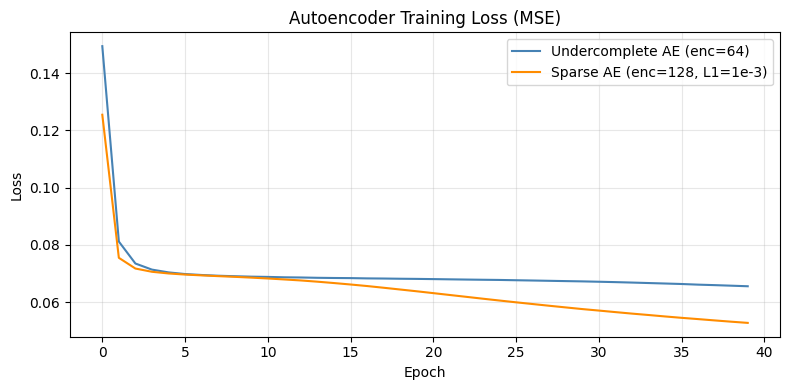

In [13]:
# ── Undercomplete autoencoder (bottleneck = 64, no sparsity) ──────────────────
print("Training Undercomplete Autoencoder (bottleneck=64) ...")
ae_under = Autoencoder(enc_dim=64, lr=0.01, sparsity=0.0)
loss_under = ae_under.fit(X_train, epochs=40, batch_size=256)

# ── Sparse autoencoder (bottleneck = 128, L1 sparsity penalty) ────────────────
print("\nTraining Sparse Autoencoder (bottleneck=128, L1=1e-3) ...")
ae_sparse = Autoencoder(enc_dim=128, lr=0.01, sparsity=1e-3)
loss_sparse = ae_sparse.fit(X_train, epochs=40, batch_size=256)

# ── Loss curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(loss_under, label='Undercomplete AE (enc=64)', color='steelblue')
plt.plot(loss_sparse, label='Sparse AE (enc=128, L1=1e-3)', color='darkorange')
plt.title('Autoencoder Training Loss (MSE)', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4b. Reconstruction Visualisation

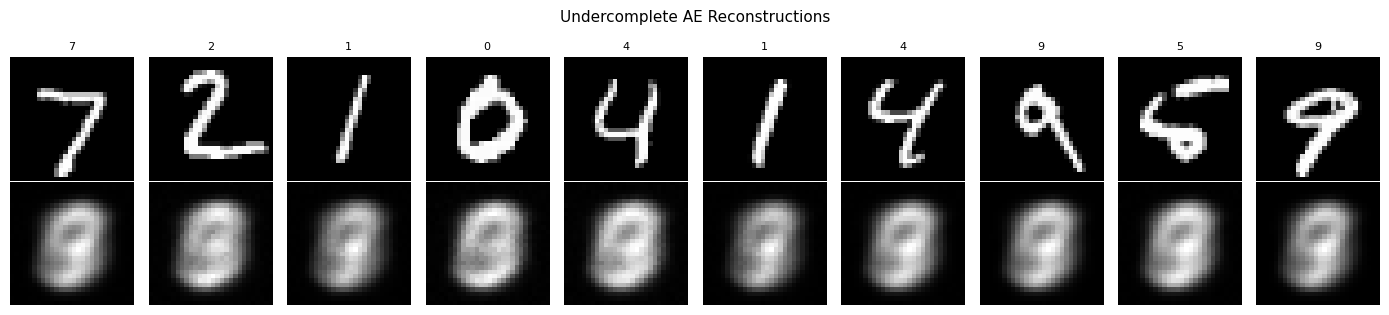

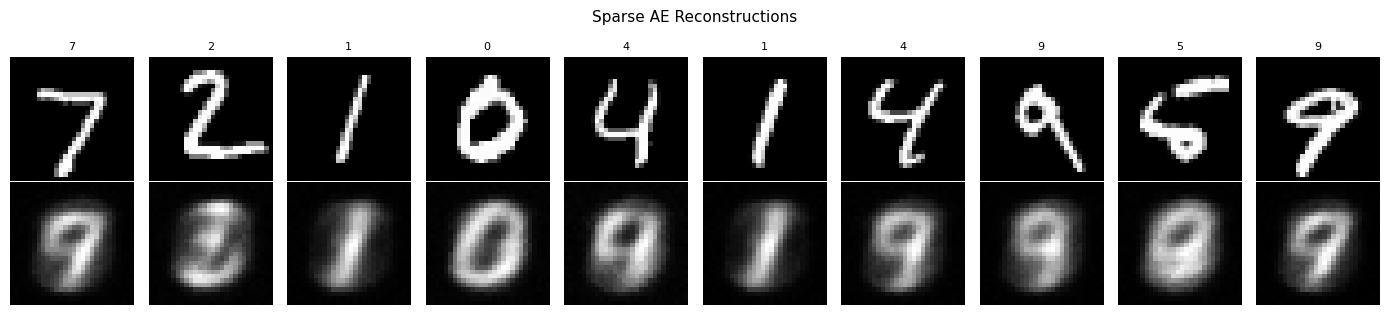

In [16]:
def show_reconstructions(ae, X, title, n=10):
    samples = X[:n]
    recons  = ae.forward(samples)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
    for i in range(n):
        axes[0, i].imshow(samples[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(str(int(y_test[i])), fontsize=8)   # digit label
        axes[0, i].axis('off')

        axes[1, i].imshow(recons[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=8)
    axes[1, 0].set_ylabel('Recon',    fontsize=8)
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()   

show_reconstructions(ae_under,  X_test, 'Undercomplete AE Reconstructions')
show_reconstructions(ae_sparse, X_test, 'Sparse AE Reconstructions')


### 4c. Outlier Detection via Reconstruction Error

Train recon error: mean=0.05187, std=0.01532
Outlier threshold : 0.08251

Noise images flagged as outlier  : 200/200 (100.0%)
Normal images flagged as outlier : 100/3000  (3.3%)


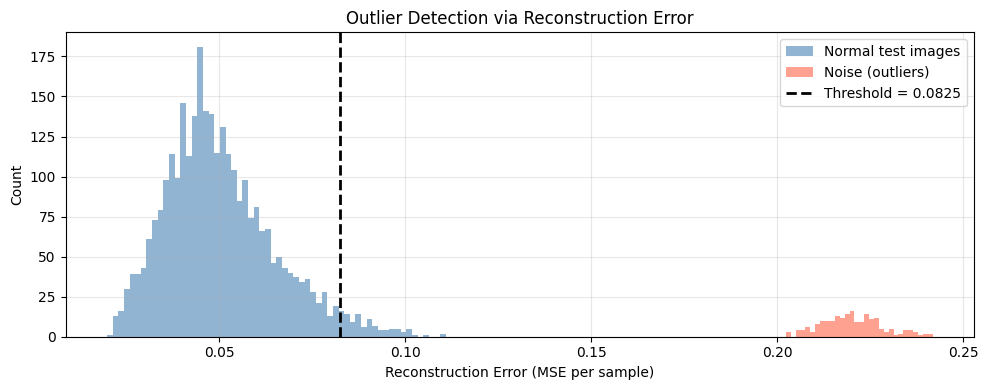

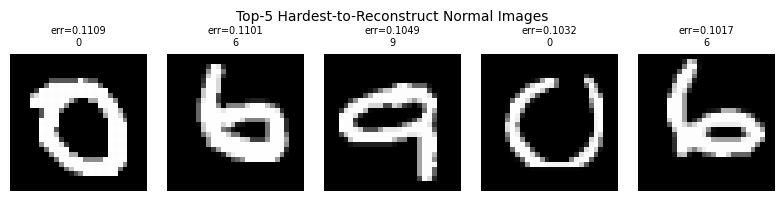

In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# OUTLIER DETECTION
# ════════════════════════════════════════════════════════════════════════════════

# ── Reconstruction errors on normal test images ────────────────────────────────
re_test  = ae_sparse.reconstruction_error(X_test)

# ── Simulated outliers: uniform random noise ──────────────────────────────────
np.random.seed(0)
n_outliers = 200
X_noise    = np.random.uniform(0, 1, (n_outliers, 784))
re_noise   = ae_sparse.reconstruction_error(X_noise)

# ── Threshold: mean + 2 standard deviations of train errors ──────────────────
re_train   = ae_sparse.reconstruction_error(X_train)
threshold  = re_train.mean() + 2 * re_train.std()
print(f"Train recon error: mean={re_train.mean():.5f}, std={re_train.std():.5f}")
print(f"Outlier threshold : {threshold:.5f}")

# ── Detection rates ────────────────────────────────────────────────────────────
tp = (re_noise > threshold).sum()
fp = (re_test  > threshold).sum()
print(f"\nNoise images flagged as outlier  : {tp}/{n_outliers} ({tp/n_outliers*100:.1f}%)")
print(f"Normal images flagged as outlier : {fp}/{len(X_test)}  ({fp/len(X_test)*100:.1f}%)")

# ── Distribution plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(re_test,  bins=60, alpha=0.6, color='steelblue',   label='Normal test images')
plt.hist(re_noise, bins=30, alpha=0.6, color='tomato',      label='Noise (outliers)')
plt.axvline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction Error (MSE per sample)')
plt.ylabel('Count')
plt.title('Outlier Detection via Reconstruction Error', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Show top-5 highest-error normal samples (edge cases / hard samples) ────────
top5_idx  = re_test.argsort()[-5:][::-1]
fig, axes = plt.subplots(1, 5, figsize=(8, 2))
for i, idx in enumerate(top5_idx):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'err={re_test[idx]:.4f}\n{CLASS_NAMES[y_test[idx]]}', fontsize=7)
    axes[i].axis('off')
plt.suptitle('Top-5 Hardest-to-Reconstruct Normal Images', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Part C — Restricted Boltzmann Machine (Contrastive Divergence)

RBMs are generative models trained with **CD-1** (1-step Contrastive Divergence).  
The weight update rule approximates the gradient of log-likelihood.

In [20]:
# ════════════════════════════════════════════════════════════════════════════════
# RESTRICTED BOLTZMANN MACHINE
# ════════════════════════════════════════════════════════════════════════════════

class RBM:
    """
    Binary RBM trained with Contrastive Divergence (CD-k, default k=1).

    Units
    -----
    Visible (v): 784 binary units (one per pixel, Bernoulli)
    Hidden  (h): n_hidden binary units (features / filters)

    Update rule (CD-1)
    ------------------
    ΔW  = lr * ( <v h>_data  −  <v h>_recon )
    Δbv = lr * ( mean(v_data)  − mean(v_recon) )
    Δbh = lr * ( mean(h_data)  − mean(h_recon) )
    """

    def __init__(self, n_visible=784, n_hidden=256, lr=0.01):
        self.lr        = lr
        self.n_visible = n_visible
        self.n_hidden  = n_hidden

        # Small Gaussian init — standard for RBMs
        self.W  = np.random.randn(n_visible, n_hidden) * 0.01
        self.bv = np.zeros((1, n_visible))              # visible biases
        self.bh = np.zeros((1, n_hidden))               # hidden  biases

    # ── Conditional probabilities ──────────────────────────────────────────────
    def p_h_given_v(self, v):
        """P(h=1|v) for each hidden unit — sigmoid of linear activation."""
        return sigmoid(v @ self.W + self.bh)

    def p_v_given_h(self, h):
        """P(v=1|h) for each visible unit — sigmoid of linear activation."""
        return sigmoid(h @ self.W.T + self.bv)

    def sample(self, prob):
        """Bernoulli sample from a probability matrix."""
        return (prob > np.random.rand(*prob.shape)).astype(float)

    # ── CD-k reconstruction ────────────────────────────────────────────────────
    def contrastive_divergence(self, v0, k=1):
        """
        Run k steps of Gibbs sampling starting from v0.
        Returns (h0_prob, v_k, h_k_prob) for weight update.
        """
        h0_prob    = self.p_h_given_v(v0)
        h0_sample  = self.sample(h0_prob)

        vk = v0.copy()
        hk_prob = h0_prob.copy()

        for _ in range(k):
            vk       = self.p_v_given_h(self.sample(hk_prob))  # mean-field v
            hk_prob  = self.p_h_given_v(vk)

        return h0_prob, vk, hk_prob

    # ── Training loop ─────────────────────────────────────────────────────────
    def fit(self, X, epochs=20, batch_size=128, k=1, verbose=True):
        errors = []
        for ep in range(epochs):
            idx = np.random.permutation(len(X))
            Xs  = X[idx]
            ep_err = []

            for i in range(0, len(X), batch_size):
                v0 = Xs[i:i+batch_size]
                m  = v0.shape[0]

                h0_prob, vk, hk_prob = self.contrastive_divergence(v0, k)

                # ── CD-1 weight update ────────────────────────────────────
                self.W  += self.lr * ((v0.T @ h0_prob) - (vk.T @ hk_prob)) / m
                self.bv += self.lr * (v0.mean(0, keepdims=True) - vk.mean(0, keepdims=True))
                self.bh += self.lr * (h0_prob.mean(0, keepdims=True) - hk_prob.mean(0, keepdims=True))

                ep_err.append(np.mean((v0 - vk) ** 2))

            avg = np.mean(ep_err)
            errors.append(avg)
            if verbose and (ep+1) % 4 == 0:
                print(f"  RBM Epoch {ep+1:3d}/{epochs}  recon_error={avg:.5f}")

        return errors

    def reconstruct(self, v):
        """One Gibbs step: v → h → v_recon."""
        h_prob = self.p_h_given_v(v)
        return self.p_v_given_h(h_prob)

print("RBM class defined ✓")


RBM class defined ✓


### 5a. Train RBM

Training RBM (n_hidden=256, CD-1) ...
  RBM Epoch   4/20  recon_error=0.06297
  RBM Epoch   8/20  recon_error=0.04904
  RBM Epoch  12/20  recon_error=0.04223
  RBM Epoch  16/20  recon_error=0.03853
  RBM Epoch  20/20  recon_error=0.03565


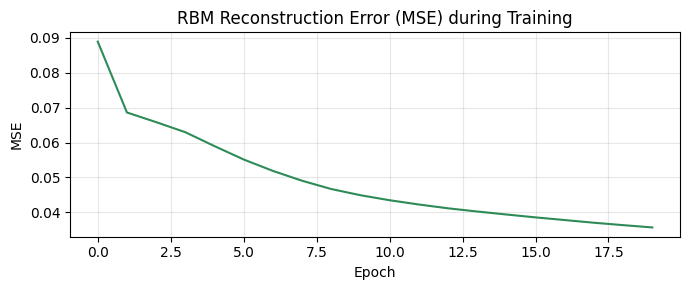

In [21]:
print("Training RBM (n_hidden=256, CD-1) ...")
rbm = RBM(n_visible=784, n_hidden=256, lr=0.01)
rbm_errors = rbm.fit(X_train[:8000], epochs=20, batch_size=128, verbose=True)

# ── Reconstruction error curve ────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.plot(rbm_errors, color='seagreen')
plt.title('RBM Reconstruction Error (MSE) during Training', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 5b. RBM Learned Filters (Weight Visualisation)

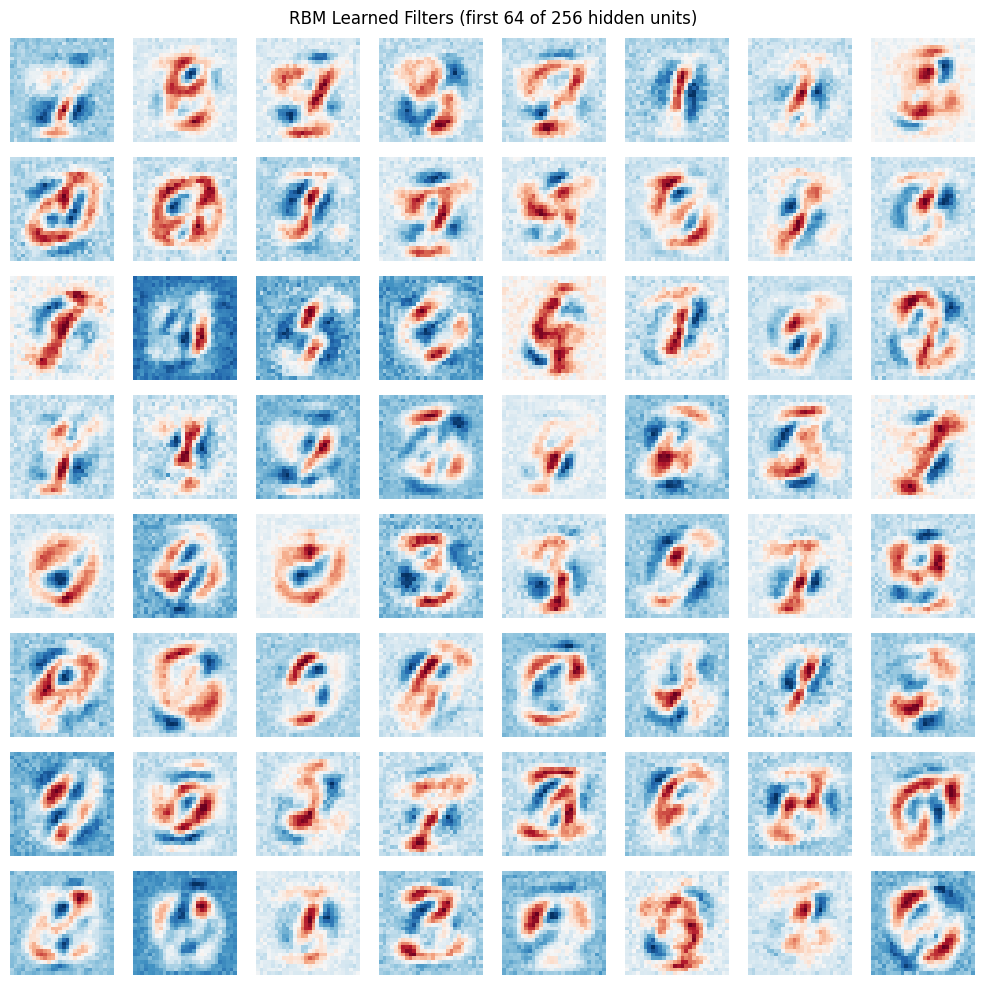

In [23]:
# ── Display first 64 RBM filters (columns of W, each 784-d) ───────────────────
n_show = 64
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    filt = rbm.W[:, i]
    filt_img = (filt - filt.min()) / (filt.max() - filt.min() + 1e-9)
    ax.imshow(filt_img.reshape(28, 28), cmap='RdBu_r')
    ax.axis('off')
plt.suptitle('RBM Learned Filters (first 64 of 256 hidden units)', fontsize=12)
plt.tight_layout()
plt.show()


### 5c. RBM Reconstructions

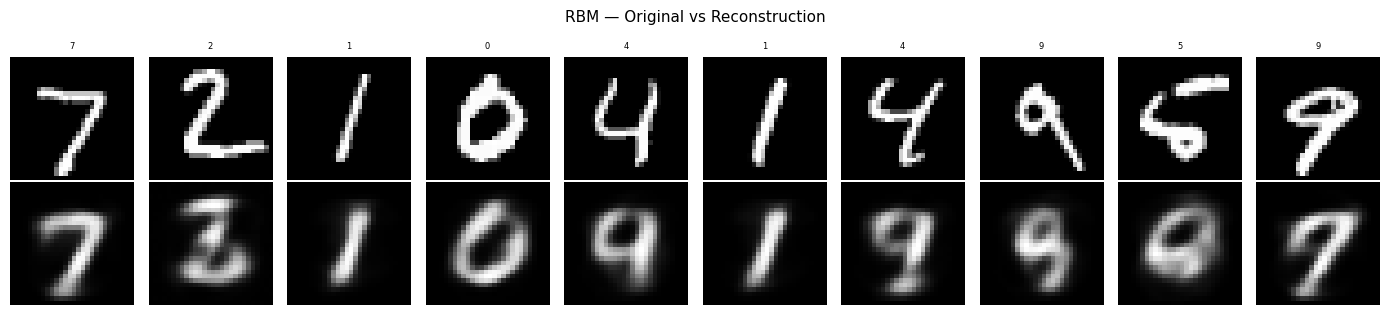

In [24]:
# ── Show original vs RBM reconstruction ──────────────────────────────────────
samples = X_test[:10]
recons  = rbm.reconstruct(samples)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for i in range(10):
    axes[0, i].imshow(samples[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(CLASS_NAMES[y_test[i]], fontsize=6)
    axes[0, i].axis('off')

    axes[1, i].imshow(recons[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=8)
axes[1, 0].set_ylabel('RBM recon', fontsize=8)
plt.suptitle('RBM — Original vs Reconstruction', fontsize=11)
plt.tight_layout()
plt.show()
